# Model 3 — Lactate curve reconstruction

This model reconstructs the full lactate curve over time using SmO₂ data.

It combines:
- the predicted lactate peak (Model 2),
- a fixed time to peak,
- and a physiological model describing the rise and decay of lactate.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

# 1) CONFIGURATION
CSV_FILES = {
    "Alexis": "../DATA/Alexis_wingate.csv",
    "Antoine": "../DATA/Antoine_wingate.csv",
    "Jinwei": "../DATA/Jinwei_wingate.csv",
    "Victor": "../DATA/Victor_wingate.csv",
}

XLS_FILE = "../DATA/Physio_Session2_Wingate.xlsx"
SHEET_NAME = "data"

# Manual SmO2 baseline values provided by the user
MANUAL_SMO2_BASELINE = {
    "Alexis": 67.0,
    "Victor": 73.0,
    "Antoine": 70.0,
    "Jinwei": 76.0,
}

# Wingate timing
START_TIME_S = 15
WINGATE_DURATION = 30
END_TIME_S = START_TIME_S + WINGATE_DURATION

# Fixed time to peak lactate
T_PEAK_MIN_FIXED = 3.0
T_PEAK_S_FIXED = END_TIME_S + T_PEAK_MIN_FIXED * 60  # 45 + 180 = 225 s

# Optional fixed lactate baseline
# If you prefer to use measured lactate baseline, set USE_MEASURED_LA_BASELINE = True
USE_MEASURED_LA_BASELINE = True
LA_BASELINE_ASSUMED = 1.5

# Reconstruction parameters
TALAC_S = 2.1
K_RISE = 4

TAU_FAST_DECAY = 300
TAU_SLOW_DECAY = 2000
W_FAST = 0.2
W_SLOW = 0.8

SLOPE_WINDOW = 10

# 6) PLOTS - one figure with several panels
n_subjects = len(model3_df)
ncols = 2
nrows = int(np.ceil(n_subjects / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.8 * nrows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

pooled_true = []
pooled_pred = []

for ax, (_, row) in zip(axes, model3_df.iterrows()):
    sid = row["id"]
    pred_curve = curve_store[sid].copy()
    t_pred = pred_curve["Time"].to_numpy(float)
    y_pred_curve = pred_curve["La_est"].to_numpy(float)

    ax.plot(pred_curve["Time"], pred_curve["La_est"], label="Custom models", linewidth=2)
    ax.axvline(START_TIME_S, linestyle="--", label="Wingate start", color="green")
    ax.axvline(END_TIME_S, linestyle="--", label="Wingate end", color="black")
    ax.axvline(T_PEAK_S_FIXED, linestyle=":", label="Fixed peak time (3 min post)")

    lac_sub = lac_all[lac_all["Name"].str.lower() == sid.lower()].copy()
    panel_true = np.array([], dtype=float)
    panel_pred = np.array([], dtype=float)

    if not lac_sub.empty:
        abs_times = []
        la_vals = []
        time_rel = []

        for _, rr in lac_sub.iterrows():
            t_rel_min = rr["Time"]
            la_val = rr["[La]"]

            if pd.isna(t_rel_min) or pd.isna(la_val):
                continue

            if t_rel_min == -1:
                t_abs = START_TIME_S - 60
            else:
                t_abs = END_TIME_S + t_rel_min * 60

            abs_times.append(t_abs)
            la_vals.append(la_val)
            time_rel.append(t_rel_min)

        ax.scatter(abs_times, la_vals, color="red", label="Measured lactate", zorder=3)

        if len(abs_times) > 0:
            y_true = np.asarray(la_vals, dtype=float)
            y_hat = np.interp(np.asarray(abs_times, dtype=float), t_pred, y_pred_curve)
            time_rel_arr = np.asarray(time_rel, dtype=float)

            # Exclude baseline (Time == -1) from all error metrics
            valid_mask = time_rel_arr != -1
            panel_true = y_true[valid_mask]
            panel_pred = y_hat[valid_mask]

            if panel_true.size > 0:
                pooled_true.extend(panel_true.tolist())
                pooled_pred.extend(panel_pred.tolist())

    if panel_true.size > 0:
        rmse_panel = float(np.sqrt(np.mean((panel_pred - panel_true) ** 2)))
        bias_panel = float(np.mean(panel_pred - panel_true))
        ss_res = float(np.sum((panel_true - panel_pred) ** 2))
        ss_tot = float(np.sum((panel_true - np.mean(panel_true)) ** 2))
        r2_panel = np.nan if np.isclose(ss_tot, 0.0) else float(1 - ss_res / ss_tot)
        r2_str = f"{r2_panel:.2f}" if np.isfinite(r2_panel) else "nan"
        ax.set_title(f"{sid} | RMSE={rmse_panel:.2f} | Bias={bias_panel:.2f} | R2={r2_str}", fontsize=16)
    else:
        ax.set_title(f"{sid} | RMSE=nan | Bias=nan | R2=nan", fontsize=16)

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Lactate (mmol/L)")
    ax.grid(True, alpha=0.3)

for i in range(n_subjects, len(axes)):
    axes[i].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
legend_ax_idx = min(n_subjects - 1, ncols - 1)
legend_x = 1.02
if handles:
    axes[legend_ax_idx].legend(handles, labels, loc="center left", bbox_to_anchor=(legend_x, 0.68), frameon=False)

pooled_n = len(pooled_true)
if pooled_n > 0:
    pooled_true = np.asarray(pooled_true, dtype=float)
    pooled_pred = np.asarray(pooled_pred, dtype=float)
    pooled_rmse = float(np.sqrt(np.mean((pooled_pred - pooled_true) ** 2)))
    pooled_bias = float(np.mean(pooled_pred - pooled_true))
    pooled_ss_res = float(np.sum((pooled_true - pooled_pred) ** 2))
    pooled_ss_tot = float(np.sum((pooled_true - np.mean(pooled_true)) ** 2))
    pooled_r2 = np.nan if np.isclose(pooled_ss_tot, 0.0) else float(1 - pooled_ss_res / pooled_ss_tot)
    pooled_r2_str = f"{pooled_r2:.3f}" if np.isfinite(pooled_r2) else "nan"
    pooled_text = (
        f"Pooled metrics (baseline excluded)\n"
        f"n = {pooled_n}\n"
        f"RMSE = {pooled_rmse:.3f}\n"
        f"Bias = {pooled_bias:.3f}\n"
        f"R2 = {pooled_r2_str}"
    )
else:
    pooled_text = "Pooled metrics (baseline excluded): no valid points"

axes[legend_ax_idx].text(
    legend_x,
    -0.20,
    pooled_text,
    transform=axes[legend_ax_idx].transAxes,
    ha="left",
    va="bottom",
    fontsize=10,
    linespacing=1.3,
    bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "alpha": 0.9, "edgecolor": "lightgray"},
)

fig.suptitle("Model 3 reconstructed lactate curves", y=1.02, fontsize=16)
fig.subplots_adjust(left=0.07, right=0.78, top=0.90, bottom=0.14, wspace=0.10, hspace=0.34)
plt.show()


# 3) HELPER FUNCTIONS

def load_trainred_csv(file_path):
    """
    Load a Train.Red CSV file and return a clean DataFrame with:
    - Time (seconds)
    - SmO2 (%)
    """
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    header_idx = None
    for i, line in enumerate(lines):
        if "Timestamp (seconds passed)" in line and "SmO2" in line:
            header_idx = i
            break

    if header_idx is None:
        raise ValueError(f"Header not found in {file_path}")

    df = pd.read_csv(file_path, skiprows=header_idx)
    df.columns = [str(c).strip() for c in df.columns]

    df = df[["Timestamp (seconds passed)", "SmO2"]].copy()
    df.columns = ["Time", "SmO2"]

    df["Time"] = pd.to_numeric(df["Time"], errors="coerce")
    df["SmO2"] = pd.to_numeric(df["SmO2"], errors="coerce")
    df = df.dropna(subset=["Time", "SmO2"]).sort_values("Time").reset_index(drop=True)

    return df


def smo2_desat_model(t, A, tau):
    """
    Exponential desaturation model:
    dSmO2(t) = A * (1 - exp(-t/tau))
    """
    return A * (1 - np.exp(-t / tau))


def fit_smo2_tau(win):
    """
    Fit the SmO2 desaturation curve and estimate:
    - A_fit: desaturation amplitude
    - tau_fit: time constant
    """
    t = win["t_rel"].to_numpy(dtype=float)
    y = win["dSmO2"].to_numpy(dtype=float)

    if np.nanmax(y) < 0.5:
        return np.nan, np.nan

    try:
        p0 = [np.nanmax(y), 5.0]
        bounds = ([0.0, 0.1], [50.0, 60.0])

        popt, _ = curve_fit(
            smo2_desat_model,
            t,
            y,
            p0=p0,
            bounds=bounds,
            maxfev=20000
        )

        return float(popt[0]), float(popt[1])
    except Exception:
        return np.nan, np.nan


def extract_features_from_manual_baseline(sm_df, sm0, start_time_s=15, duration_s=30):
    """
    Extract SmO2 features during the Wingate test using a manually imposed baseline.
    """
    sm = sm_df.copy()

    win = sm[(sm["Time"] >= start_time_s) &
             (sm["Time"] <= start_time_s + duration_s)].copy()

    if len(win) < 5:
        raise ValueError("Wingate window too short")

    win["t_rel"] = win["Time"] - start_time_s
    win["dSmO2"] = (sm0 - win["SmO2"]).clip(lower=0)

    dt = float(np.mean(np.diff(win["Time"])))
    if not np.isfinite(dt) or dt <= 0:
        raise ValueError("Invalid dt inside Wingate window")

    auc_30 = float(np.sum(win["dSmO2"]) * dt)
    min_smo2 = float(win["SmO2"].min())
    dmax = float(win["dSmO2"].max())

    early = win[win["t_rel"] <= SLOPE_WINDOW].copy()
    if len(early) >= 3:
        slope_0_10 = float(np.polyfit(early["t_rel"], early["SmO2"], 1)[0])
    else:
        slope_0_10 = np.nan

    A_fit, tau_fit = fit_smo2_tau(win)

    return {
        "sm_window": win,
        "SmO2_baseline": sm0,
        "AUC_30s": auc_30,
        "SmO2_min": min_smo2,
        "dSmO2_max": dmax,
        "slope_0_10": slope_0_10,
        "A_fit": A_fit,
        "tau_SmO2": tau_fit
    }



## Curve reconstruction

The rise of lactate is modeled with a smooth exponential increase.

The decay phase is modeled using a bi-exponential function:
- a fast component (short-term clearance),
- a slow component (long-term clearance).

This reflects known physiological behavior of lactate after intense exercise.


===== MODEL 3 SUMMARY =====
        id  SmO2_baseline_manual     AUC_30s   tau_SmO2  dSmO2_max  \
0   Alexis                  67.0  114.459276  12.724950       6.32   
1  Antoine                  70.0  142.749000  20.716215       8.11   
2   Jinwei                  76.0  396.703000   0.100000      14.33   
3   Victor                  73.0  291.037500   5.012716      12.32   

   slope_0_10  Delta_La_peak_pred  La_baseline_used  La_peak_pred  \
0   -0.551072           13.199882              1.70     14.899882   
1   -0.301603           15.003786              2.20     17.203786   
2   -0.114292           14.406042              2.50     16.906042   
3   -0.551072           14.020398              0.75     14.770398   

   T_peak_min_fixed  La_peak_measured  Delta_La_peak_measured  
0               3.0              16.1                   14.40  
1               3.0              17.3                   15.10  
2               3.0              13.9                   11.40  
3               3.

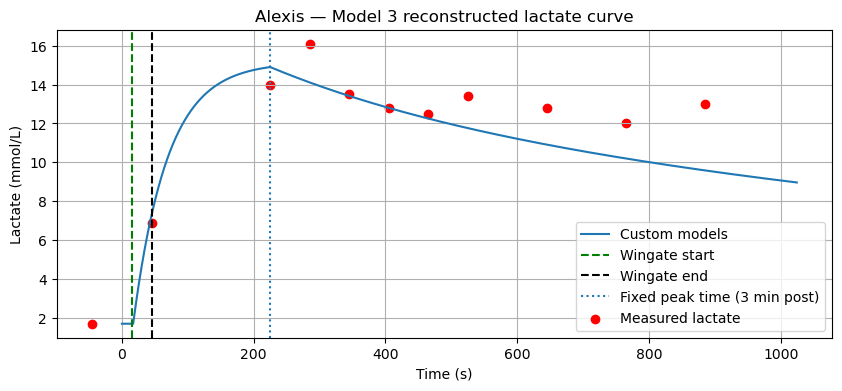

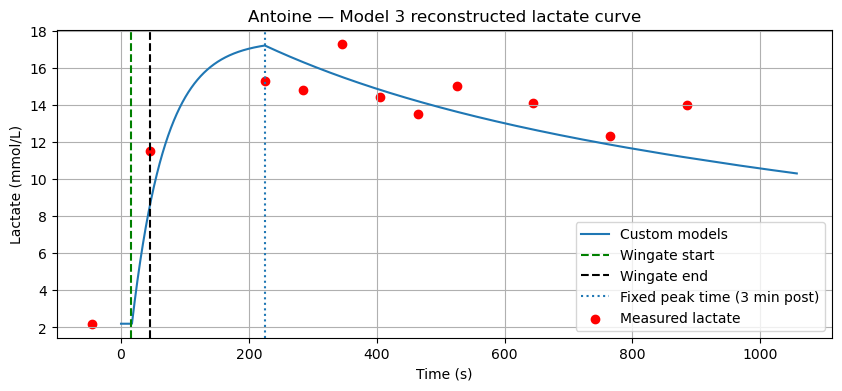

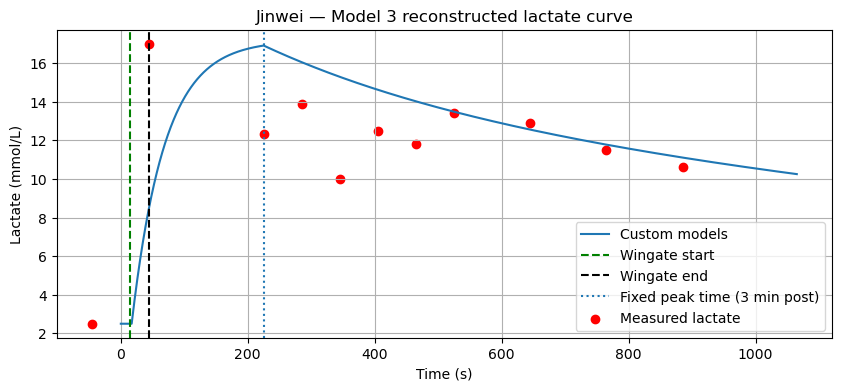

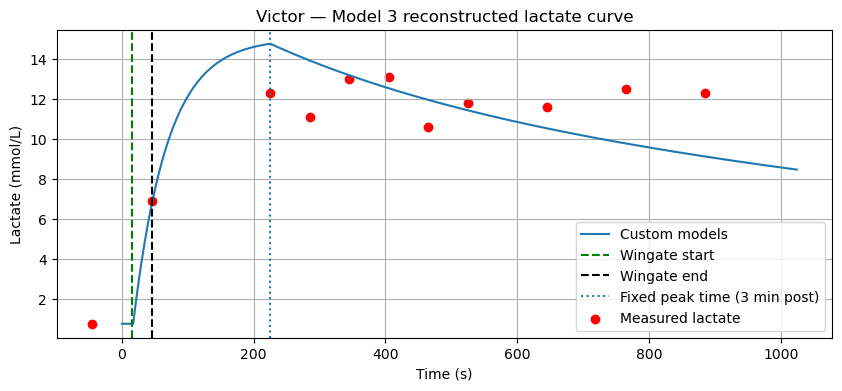

In [40]:

def fast_exponential_rise(frac, k=5.0):
    """
    Fast rise with saturation.
    frac must be between 0 and 1.
    """
    frac = np.clip(frac, 0, 1)
    rise = 1 - np.exp(-k * frac)
    rise = rise / (1 - np.exp(-k))
    return rise


def biexponential_decay(t_after_peak, la_base, delta_peak,
                        tau_fast=300, tau_slow=1800,
                        w_fast=0.30, w_slow=0.70):
    """
    Bi-exponential post-peak decay.
    """
    return la_base + delta_peak * (
        w_fast * np.exp(-t_after_peak / tau_fast) +
        w_slow * np.exp(-t_after_peak / tau_slow)
    )
    
def reconstruct_lactate_curve(sm_full, la_base, delta_peak,
                              start_time_s=15,
                              t_peak_s=225):
    """
    Reconstruct the full lactate curve:
    - baseline before exercise
    - fast rise after exercise
    - fixed peak at t_peak_s
    - bi-exponential decay
    """
    pred = sm_full[["Time"]].copy()
    pred["La_est"] = np.nan

    rise_start = start_time_s + TALAC_S
    rise_end = t_peak_s

    for i, t in enumerate(pred["Time"].to_numpy(float)):
        if t < rise_start:
            pred.loc[i, "La_est"] = la_base

        elif t <= rise_end:
            frac = (t - rise_start) / (rise_end - rise_start)
            rise = fast_exponential_rise(frac, k=K_RISE)
            pred.loc[i, "La_est"] = la_base + rise * delta_peak

        else:
            t_after_peak = t - rise_end
            pred.loc[i, "La_est"] = biexponential_decay(
                t_after_peak=t_after_peak,
                la_base=la_base,
                delta_peak=delta_peak,
                tau_fast=TAU_FAST_DECAY,
                tau_slow=TAU_SLOW_DECAY,
                w_fast=W_FAST,
                w_slow=W_SLOW
            )

    return pred
    


def summarize_lactate_subject(lac_subject):
    """
    Extract measured lactate summary for plotting.
    """
    lac_subject = lac_subject.sort_values("Time").copy()

    base_row = lac_subject[lac_subject["Time"] == -1]
    la_baseline = float(base_row["[La]"].iloc[0]) if not base_row.empty else np.nan

    post = lac_subject[lac_subject["Time"] > 0]
    if post.empty:
        la_peak = np.nan
        t_peak = np.nan
        delta_peak = np.nan
    else:
        idx_peak = post["[La]"].idxmax()
        la_peak = float(post.loc[idx_peak, "[La]"])
        t_peak = float(post.loc[idx_peak, "Time"])
        delta_peak = la_peak - la_baseline if np.isfinite(la_baseline) else np.nan

    return {
        "La_baseline": la_baseline,
        "La_peak": la_peak,
        "Time_peak_min": t_peak,
        "Delta_La_peak": delta_peak
    }


# 4) LOAD MEASURED LACTATE TABLE

lac_all = pd.read_excel(XLS_FILE, sheet_name=SHEET_NAME)
lac_all.columns = [str(c).strip() for c in lac_all.columns]
lac_all["Time"] = pd.to_numeric(lac_all["Time"], errors="coerce")
lac_all["[La]"] = pd.to_numeric(lac_all["[La]"], errors="coerce")


# 5) APPLY MODEL 3 TO ALL SUBJECTS

rows = []
curve_store = {}
sm_store = {}

for subject, csv_file in CSV_FILES.items():
    sm = load_trainred_csv(csv_file)
    sm_store[subject] = sm.copy()

    sm0 = MANUAL_SMO2_BASELINE[subject]

    feat = extract_features_from_manual_baseline(
        sm_df=sm,
        sm0=sm0,
        start_time_s=START_TIME_S,
        duration_s=WINGATE_DURATION
    )

    # Model 2 prediction
    delta_peak_pred = (
        B0
        + B1 * feat["AUC_30s"]
        + B2 * feat["tau_SmO2"]
        + B3 * feat["dSmO2_max"]
        + B4 * feat["slope_0_10"]
    )

    delta_peak_pred = max(delta_peak_pred, 0.0)

    # Lactate baseline
    lac_sub = lac_all[lac_all["Name"].str.lower() == subject.lower()].copy()
    lac_summary = summarize_lactate_subject(lac_sub)

    if USE_MEASURED_LA_BASELINE and np.isfinite(lac_summary["La_baseline"]):
        la_base = lac_summary["La_baseline"]
    else:
        la_base = LA_BASELINE_ASSUMED

    la_peak_pred = la_base + delta_peak_pred

    pred_curve = reconstruct_lactate_curve(
        sm_full=sm,
        la_base=la_base,
        delta_peak=delta_peak_pred,
        start_time_s=START_TIME_S,
        t_peak_s=T_PEAK_S_FIXED
    )

    curve_store[subject] = pred_curve

    rows.append({
        "id": subject,
        "SmO2_baseline_manual": sm0,
        "AUC_30s": feat["AUC_30s"],
        "tau_SmO2": feat["tau_SmO2"],
        "dSmO2_max": feat["dSmO2_max"],
        "slope_0_10": feat["slope_0_10"],
        "Delta_La_peak_pred": delta_peak_pred,
        "La_baseline_used": la_base,
        "La_peak_pred": la_peak_pred,
        "T_peak_min_fixed": T_PEAK_MIN_FIXED,
        "La_peak_measured": lac_summary["La_peak"],
        "Delta_La_peak_measured": lac_summary["Delta_La_peak"]
    })

model3_df = pd.DataFrame(rows)

print("\n===== MODEL 3 SUMMARY =====")
print(model3_df)


# 6) PLOTS

for _, row in model3_df.iterrows():
    sid = row["id"]
    pred_curve = curve_store[sid].copy()

    plt.figure(figsize=(10, 4))
    plt.plot(pred_curve["Time"], pred_curve["La_est"], label="Custom models")
    plt.axvline(START_TIME_S, linestyle="--", label="Wingate start", color="green")
    plt.axvline(END_TIME_S, linestyle="--", label="Wingate end", color="black")
    plt.axvline(T_PEAK_S_FIXED, linestyle=":", label="Fixed peak time (3 min post)")

    # Measured lactate points
    lac_sub = lac_all[lac_all["Name"].str.lower() == sid.lower()].copy()
    if not lac_sub.empty:
        abs_times = []
        la_vals = []

        for _, rr in lac_sub.iterrows():
            t_rel_min = rr["Time"]
            la_val = rr["[La]"]

            if pd.isna(t_rel_min) or pd.isna(la_val):
                continue

            if t_rel_min == -1:
                t_abs = START_TIME_S - 60
            else:
                t_abs = END_TIME_S + t_rel_min * 60

            abs_times.append(t_abs)
            la_vals.append(la_val)

        plt.scatter(abs_times, la_vals, color="red", label="Measured lactate")

    plt.xlabel("Time (s)")
    plt.ylabel("Lactate (mmol/L)")
    plt.title(f"{sid} — Model 3 reconstructed lactate curve")
    plt.grid(True)
    plt.legend()
    plt.show()



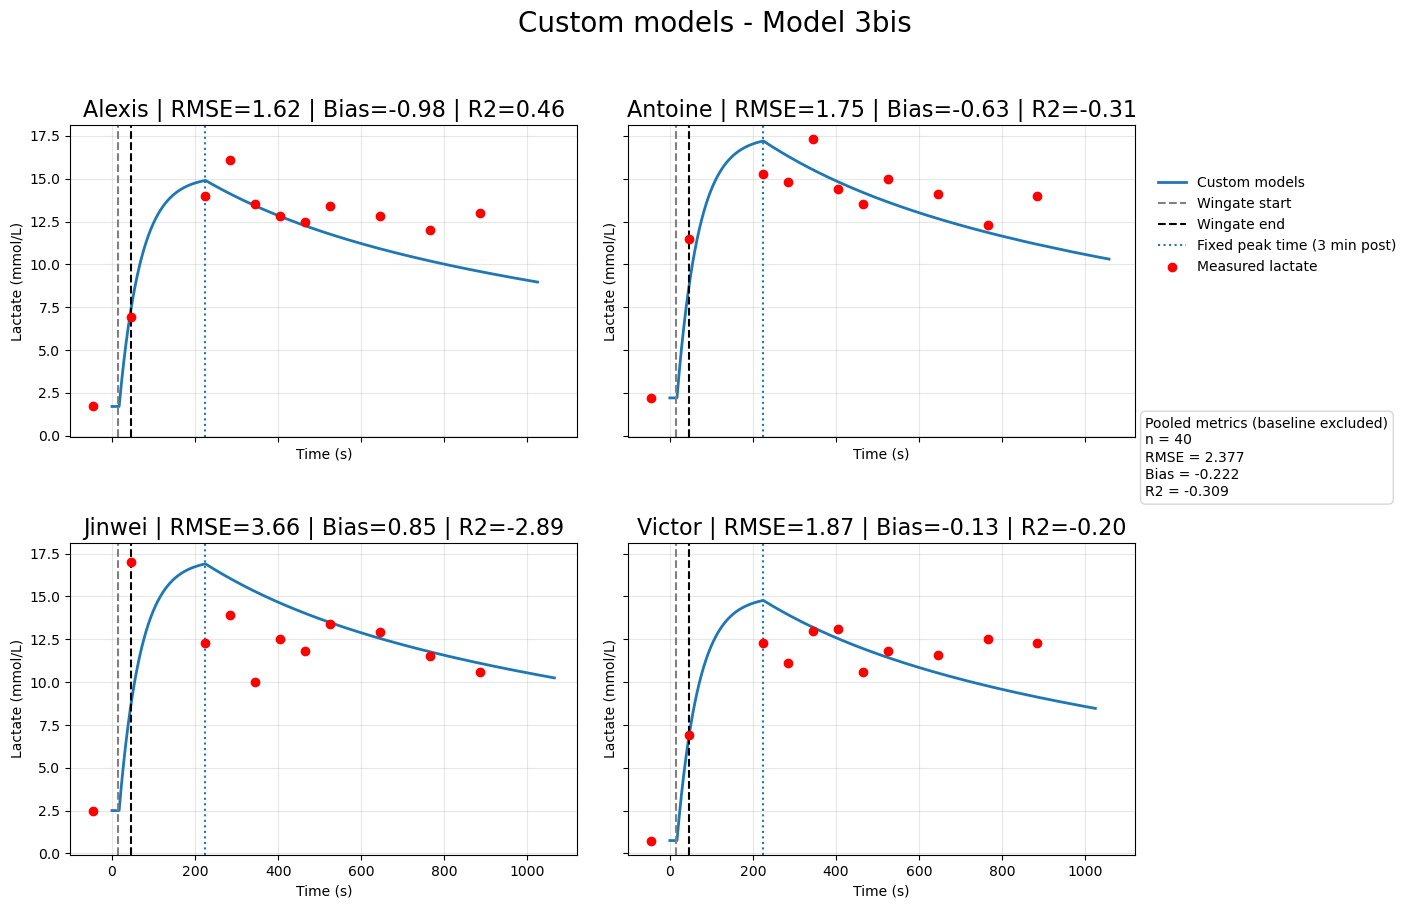

In [43]:
# Combined panels with baseline-excluded error metrics
n_subjects = len(model3_df)
ncols = 2
nrows = int(np.ceil(n_subjects / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.8 * nrows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

pooled_true = []
pooled_pred = []

for ax, (_, row) in zip(axes, model3_df.iterrows()):
    sid = row["id"]
    pred_curve = curve_store[sid].copy()
    t_pred = pred_curve["Time"].to_numpy(float)
    y_pred_curve = pred_curve["La_est"].to_numpy(float)

    ax.plot(pred_curve["Time"], pred_curve["La_est"], label="Custom models", linewidth=2)
    ax.axvline(START_TIME_S, linestyle="--", label="Wingate start", color="gray")
    ax.axvline(END_TIME_S, linestyle="--", label="Wingate end", color="black")
    ax.axvline(T_PEAK_S_FIXED, linestyle=":", label="Fixed peak time (3 min post)")

    lac_sub = lac_all[lac_all["Name"].str.lower() == sid.lower()].copy()
    panel_true = np.array([], dtype=float)
    panel_pred = np.array([], dtype=float)

    if not lac_sub.empty:
        abs_times = []
        la_vals = []
        time_rel = []

        for _, rr in lac_sub.iterrows():
            t_rel_min = rr["Time"]
            la_val = rr["[La]"]

            if pd.isna(t_rel_min) or pd.isna(la_val):
                continue

            if t_rel_min == -1:
                t_abs = START_TIME_S - 60
            else:
                t_abs = END_TIME_S + t_rel_min * 60

            abs_times.append(t_abs)
            la_vals.append(la_val)
            time_rel.append(t_rel_min)

        ax.scatter(abs_times, la_vals, color="red", label="Measured lactate", zorder=3)

        if len(abs_times) > 0:
            y_true = np.asarray(la_vals, dtype=float)
            y_hat = np.interp(np.asarray(abs_times, dtype=float), t_pred, y_pred_curve)
            time_rel_arr = np.asarray(time_rel, dtype=float)

            # Exclude baseline (Time == -1) from all metrics
            valid_mask = time_rel_arr != -1
            panel_true = y_true[valid_mask]
            panel_pred = y_hat[valid_mask]

            if panel_true.size > 0:
                pooled_true.extend(panel_true.tolist())
                pooled_pred.extend(panel_pred.tolist())

    if panel_true.size > 0:
        rmse_panel = float(np.sqrt(np.mean((panel_pred - panel_true) ** 2)))
        bias_panel = float(np.mean(panel_pred - panel_true))
        ss_res = float(np.sum((panel_true - panel_pred) ** 2))
        ss_tot = float(np.sum((panel_true - np.mean(panel_true)) ** 2))
        r2_panel = np.nan if np.isclose(ss_tot, 0.0) else float(1 - ss_res / ss_tot)
        r2_str = f"{r2_panel:.2f}" if np.isfinite(r2_panel) else "nan"
        ax.set_title(f"{sid} | RMSE={rmse_panel:.2f} | Bias={bias_panel:.2f} | R2={r2_str}", fontsize=16)
    else:
        ax.set_title(f"{sid} | RMSE=nan | Bias=nan | R2=nan", fontsize=14)

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Lactate (mmol/L)")
    ax.grid(True, alpha=0.3)

for i in range(n_subjects, len(axes)):
    axes[i].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
legend_ax_idx = min(n_subjects - 1, ncols - 1)
legend_x = 1.02
if handles:
    axes[legend_ax_idx].legend(
        handles,
        labels,
        loc="center left",
        bbox_to_anchor=(legend_x, 0.68),
        frameon=False
    )

pooled_n = len(pooled_true)
if pooled_n > 0:
    pooled_true = np.asarray(pooled_true, dtype=float)
    pooled_pred = np.asarray(pooled_pred, dtype=float)
    pooled_rmse = float(np.sqrt(np.mean((pooled_pred - pooled_true) ** 2)))
    pooled_bias = float(np.mean(pooled_pred - pooled_true))
    pooled_ss_res = float(np.sum((pooled_true - pooled_pred) ** 2))
    pooled_ss_tot = float(np.sum((pooled_true - np.mean(pooled_true)) ** 2))
    pooled_r2 = np.nan if np.isclose(pooled_ss_tot, 0.0) else float(1 - pooled_ss_res / pooled_ss_tot)
    pooled_r2_str = f"{pooled_r2:.3f}" if np.isfinite(pooled_r2) else "nan"
    pooled_text = (
        f"Pooled metrics (baseline excluded)\n"
        f"n = {pooled_n}\n"
        f"RMSE = {pooled_rmse:.3f}\n"
        f"Bias = {pooled_bias:.3f}\n"
        f"R2 = {pooled_r2_str}"
    )
else:
    pooled_text = "Pooled metrics (baseline excluded): no valid points"

axes[legend_ax_idx].text(
    legend_x,
    -0.20,
    pooled_text,
    transform=axes[legend_ax_idx].transAxes,
    ha="left",
    va="bottom",
    fontsize=10,
    linespacing=1.3,
    bbox={
        "boxstyle": "round,pad=0.35",
        "facecolor": "white",
        "alpha": 0.9,
        "edgecolor": "lightgray"
    },
)

fig.suptitle("Custom models - Model 3bis", y=1.02, fontsize=20)
fig.subplots_adjust(left=0.07, right=0.78, top=0.90, bottom=0.14, wspace=0.10, hspace=0.34)
plt.show()

In [45]:
# Peak value and peak time error metrics table (RMSE, Bias, R2)

peak_rows = []

for _, row in model3_df.iterrows():
    sid = row["id"]
    la_peak_pred = row.get("La_peak_pred", np.nan)
    t_peak_pred_min = row.get("T_peak_min_fixed", np.nan)

    lac_sub = lac_all[lac_all["Name"].str.lower() == str(sid).lower()].copy()
    lac_sub = lac_sub[pd.to_numeric(lac_sub["Time"], errors="coerce").notna()]
    lac_sub = lac_sub[pd.to_numeric(lac_sub["[La]"], errors="coerce").notna()]
    lac_sub["Time"] = lac_sub["Time"].astype(float)
    lac_sub["[La]"] = lac_sub["[La]"].astype(float)

    # Peak time/value from measured post-exercise points (Time > 0)
    post = lac_sub[lac_sub["Time"] > 0].copy()
    if post.empty:
        la_peak_measured = np.nan
        t_peak_measured_min = np.nan
    else:
        idx_peak = post["[La]"].idxmax()
        la_peak_measured = float(post.loc[idx_peak, "[La]"])
        t_peak_measured_min = float(post.loc[idx_peak, "Time"])

    peak_rows.append({
        "id": sid,
        "La_peak_measured": la_peak_measured,
        "La_peak_pred": float(la_peak_pred) if pd.notna(la_peak_pred) else np.nan,
        "T_peak_measured_min": t_peak_measured_min,
        "T_peak_pred_min": float(t_peak_pred_min) if pd.notna(t_peak_pred_min) else np.nan,
    })

peak_df = pd.DataFrame(peak_rows)

# Compute per-subject errors
peak_df["Error_value"] = peak_df["La_peak_pred"] - peak_df["La_peak_measured"]
peak_df["RMSE_value"] = np.sqrt(peak_df["Error_value"] ** 2)
peak_df["Bias_value"] = peak_df["Error_value"]
peak_df["R2_value"] = np.nan  # not defined for single-point subject metric

peak_df["Error_time_min"] = peak_df["T_peak_pred_min"] - peak_df["T_peak_measured_min"]
peak_df["RMSE_time_min"] = np.sqrt(peak_df["Error_time_min"] ** 2)
peak_df["Bias_time_min"] = peak_df["Error_time_min"]
peak_df["R2_time"] = np.nan  # not defined for single-point subject metric

subject_table = peak_df[[
    "id",
    "La_peak_measured",
    "La_peak_pred",
    "RMSE_value",
    "Bias_value",
    "R2_value",
    "T_peak_measured_min",
    "T_peak_pred_min",
    "RMSE_time_min",
    "Bias_time_min",
    "R2_time",
]].copy()

print("\n===== PEAK VALUE + PEAK TIME METRICS BY SUBJECT =====")
display(subject_table)

# Pooled metrics for peak value
value_valid = peak_df[["La_peak_measured", "La_peak_pred"]].dropna()
if len(value_valid) > 0:
    y_true_val = value_valid["La_peak_measured"].to_numpy(float)
    y_pred_val = value_valid["La_peak_pred"].to_numpy(float)
    rmse_value_pooled = float(np.sqrt(np.mean((y_pred_val - y_true_val) ** 2)))
    bias_value_pooled = float(np.mean(y_pred_val - y_true_val))
    ss_res_val = float(np.sum((y_true_val - y_pred_val) ** 2))
    ss_tot_val = float(np.sum((y_true_val - np.mean(y_true_val)) ** 2))
    r2_value_pooled = np.nan if np.isclose(ss_tot_val, 0.0) else float(1 - ss_res_val / ss_tot_val)
else:
    rmse_value_pooled = np.nan
    bias_value_pooled = np.nan
    r2_value_pooled = np.nan

# Pooled metrics for peak time
time_valid = peak_df[["T_peak_measured_min", "T_peak_pred_min"]].dropna()
if len(time_valid) > 0:
    y_true_time = time_valid["T_peak_measured_min"].to_numpy(float)
    y_pred_time = time_valid["T_peak_pred_min"].to_numpy(float)
    rmse_time_pooled = float(np.sqrt(np.mean((y_pred_time - y_true_time) ** 2)))
    bias_time_pooled = float(np.mean(y_pred_time - y_true_time))
    ss_res_time = float(np.sum((y_true_time - y_pred_time) ** 2))
    ss_tot_time = float(np.sum((y_true_time - np.mean(y_true_time)) ** 2))
    r2_time_pooled = np.nan if np.isclose(ss_tot_time, 0.0) else float(1 - ss_res_time / ss_tot_time)
else:
    rmse_time_pooled = np.nan
    bias_time_pooled = np.nan
    r2_time_pooled = np.nan

pooled_table = pd.DataFrame([
    {
        "n_subjects_value": int(len(value_valid)),
        "RMSE_peak_value": rmse_value_pooled,
        "Bias_peak_value": bias_value_pooled,
        "R2_peak_value": r2_value_pooled,
        "n_subjects_time": int(len(time_valid)),
        "RMSE_peak_time_min": rmse_time_pooled,
        "Bias_peak_time_min": bias_time_pooled,
        "R2_peak_time": r2_time_pooled,
    }
])

print("\n===== POOLED METRICS (PEAK VALUE + PEAK TIME) =====")
display(pooled_table)


===== PEAK VALUE + PEAK TIME METRICS BY SUBJECT =====


,id,La_peak_measured,La_peak_pred,RMSE_value,Bias_value,R2_value,T_peak_measured_min,T_peak_pred_min,RMSE_time_min,Bias_time_min,R2_time
0,Alexis,16.1,14.899882,1.200118,-1.200118,NaN,4.0,3.0,1.0,-1.0,NaN
1,Antoine,17.3,17.203786,0.096214,-0.096214,NaN,5.0,3.0,2.0,-2.0,NaN
2,Jinwei,13.9,16.906042,3.006042,3.006042,NaN,4.0,3.0,1.0,-1.0,NaN
3,Victor,13.1,14.770398,1.670398,1.670398,NaN,6.0,3.0,3.0,-3.0,NaN



===== POOLED METRICS (PEAK VALUE + PEAK TIME) =====


,n_subjects_value,RMSE_peak_value,Bias_peak_value,R2_peak_value,n_subjects_time,RMSE_peak_time_min,Bias_peak_time_min,R2_peak_time
0,4,1.821816,0.845027,-0.176955,4,1.936492,-1.75,-4.454545
